In [1]:
!pip install transformers pandas torch

import pandas as pd
from transformers import pipeline

In [2]:
meals_path = "data/output/processed/meals_cleaned.csv"

meals_df = pd.read_csv(meals_path)

meals_df.head()


,meal_id,meal_name,category,restaurant,brand,price_egp,description,nutrition_grade,energy_kcal,fat_g,carbs_g,protein_g,image_url,rating,num_ratings,prep_time_min,is_available,source,calories,scraped_at
0,4001724039143,Ristorante Pizza Vegetale,Pizzas,Fresh & Fit,Dr. Oetker Ristorante,48.0,"WEIZENMEHL, 15% Tomatenpüree, 12% KÄSE (schnit...",c,192.727273,7.9,22.0,6.7,https://images.openfoodfacts.org/images/produc...,3.9,106,38,True,OpenFoodFacts,NaN,2026-04-30 22:26:45
1,4001724039112,Pizza,Pizzas,The Grill House,Dr. Oetker Ristorante,125.0,"WEIZENMEHL, 24% schnittfester MOZZARELLA KÄSE,...",c,243.661972,12.0,23.0,10.0,https://images.openfoodfacts.org/images/produc...,4.0,755,35,True,OpenFoodFacts,NaN,2026-04-30 22:26:45
2,3242272346050,Dolce Pizza Prosciutto,Pizzas,Flavor Street,Sodebo,113.0,Pâte fine à pizza (farines de blé et de blé ma...,c,205.000000,5.0,27.0,12.0,https://images.openfoodfacts.org/images/produc...,4.2,1373,43,True,OpenFoodFacts,NaN,2026-04-30 22:26:45
3,3038352876506,Tomapizza,Pizzas,Urban Bites,Panzani,49.0,tomato pulp with pieces and tomato puree (67%)...,b,47.000000,1.4,6.5,1.5,https://images.openfoodfacts.org/images/produc...,4.8,845,19,True,OpenFoodFacts,NaN,2026-04-30 22:26:45
4,3242272347552,Dolce Pizza - Regina,Pizzas,Royal Kitchen,Sodebo,144.0,Garniture 61% : sauce tomate 32% (purée de tom...,c,179.000000,3.7,25.0,10.0,https://images.openfoodfacts.org/images/produc...,3.9,1180,30,True,OpenFoodFacts,NaN,2026-04-30 22:26:45


In [3]:
reviews_path = "data/output/processed/reviews.csv"

reviews_df = pd.read_csv(reviews_path)

reviews_df.head()

,review_id,meal_id,meal_name,restaurant,rating,review_text,sentiment_label,review_date,helpful_votes
0,R000001,M0001,Classic Beef Burger,Mama's Kitchen,1.9,Disappointed with the quality. Not what I expe...,negative,2026-03-19,8
1,R000002,M0001,Classic Beef Burger,Mama's Kitchen,3.8,"Pretty good, I've had better but wouldn't say ...",neutral,2026-04-05,44
2,R000003,M0001,Classic Beef Burger,Mama's Kitchen,4.0,Super fast delivery and the food was outstandi...,positive,2026-02-01,50
3,R000004,M0001,Classic Beef Burger,Mama's Kitchen,4.7,Perfect seasoning and amazing presentation. Wo...,positive,2025-12-14,10
4,R000005,M0001,Classic Beef Burger,Mama's Kitchen,4.0,Loved every bite. The packaging was also excel...,positive,2025-10-24,20


In [4]:
sentiment_model = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

c:\Users\HP\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [5]:
def analyze_sentiment(text):
    if pd.isna(text):
        return {"sentiment": "NEUTRAL", "confidence": 0, "score": 0}
    
    result = sentiment_model(str(text)[:512])[0]  # limit tokens
    
    label = result['label']
    confidence = result['score']
    
    if label == "POSITIVE":
        score = 1
    elif label == "NEGATIVE":
        score = -1
    else:
        score = 0
        
    return {
        "sentiment": label,
        "confidence": confidence,
        "score": score
    }

In [6]:
results = reviews_df['review_text'].apply(analyze_sentiment)

reviews_df['sentiment'] = results.apply(lambda x: x['sentiment'])
reviews_df['confidence'] = results.apply(lambda x: x['confidence'])
reviews_df['sentiment_score'] = results.apply(lambda x: x['score'])

reviews_df.head()

,review_id,meal_id,meal_name,restaurant,rating,review_text,sentiment_label,review_date,helpful_votes,sentiment,confidence,sentiment_score
0,R000001,M0001,Classic Beef Burger,Mama's Kitchen,1.9,Disappointed with the quality. Not what I expe...,negative,2026-03-19,8,NEGATIVE,0.999816,-1
1,R000002,M0001,Classic Beef Burger,Mama's Kitchen,3.8,"Pretty good, I've had better but wouldn't say ...",neutral,2026-04-05,44,NEGATIVE,0.897517,-1
2,R000003,M0001,Classic Beef Burger,Mama's Kitchen,4.0,Super fast delivery and the food was outstandi...,positive,2026-02-01,50,POSITIVE,0.999868,1
3,R000004,M0001,Classic Beef Burger,Mama's Kitchen,4.7,Perfect seasoning and amazing presentation. Wo...,positive,2025-12-14,10,POSITIVE,0.999890,1
4,R000005,M0001,Classic Beef Burger,Mama's Kitchen,4.0,Loved every bite. The packaging was also excel...,positive,2025-10-24,20,POSITIVE,0.999867,1


In [7]:
meal_sentiment = reviews_df.groupby('meal_name')['sentiment_score'].mean().reset_index()

meal_sentiment.rename(columns={'sentiment_score': 'avg_sentiment'}, inplace=True)

meal_sentiment.head()

,meal_name,avg_sentiment
0,Avocado Smoothie,0.485714
1,Bbq Bacon Burger,0.371429
2,Bbq Chicken Pizza,0.350000
3,Blt Sandwich,0.600000
4,Caesar Salad,0.500000


In [8]:
final_df = meals_df.merge(meal_sentiment, on="meal_name", how="left")

final_df['avg_sentiment'] = final_df['avg_sentiment'].fillna(0)

final_df.head()

,meal_id,meal_name,category,restaurant,brand,price_egp,description,nutrition_grade,energy_kcal,fat_g,...,protein_g,image_url,rating,num_ratings,prep_time_min,is_available,source,calories,scraped_at,avg_sentiment
0,4001724039143,Ristorante Pizza Vegetale,Pizzas,Fresh & Fit,Dr. Oetker Ristorante,48.0,"WEIZENMEHL, 15% Tomatenpüree, 12% KÄSE (schnit...",c,192.727273,7.9,...,6.7,https://images.openfoodfacts.org/images/produc...,3.9,106,38,True,OpenFoodFacts,NaN,2026-04-30 22:26:45,0.0
1,4001724039112,Pizza,Pizzas,The Grill House,Dr. Oetker Ristorante,125.0,"WEIZENMEHL, 24% schnittfester MOZZARELLA KÄSE,...",c,243.661972,12.0,...,10.0,https://images.openfoodfacts.org/images/produc...,4.0,755,35,True,OpenFoodFacts,NaN,2026-04-30 22:26:45,0.0
2,3242272346050,Dolce Pizza Prosciutto,Pizzas,Flavor Street,Sodebo,113.0,Pâte fine à pizza (farines de blé et de blé ma...,c,205.000000,5.0,...,12.0,https://images.openfoodfacts.org/images/produc...,4.2,1373,43,True,OpenFoodFacts,NaN,2026-04-30 22:26:45,0.0
3,3038352876506,Tomapizza,Pizzas,Urban Bites,Panzani,49.0,tomato pulp with pieces and tomato puree (67%)...,b,47.000000,1.4,...,1.5,https://images.openfoodfacts.org/images/produc...,4.8,845,19,True,OpenFoodFacts,NaN,2026-04-30 22:26:45,0.0
4,3242272347552,Dolce Pizza - Regina,Pizzas,Royal Kitchen,Sodebo,144.0,Garniture 61% : sauce tomate 32% (purée de tom...,c,179.000000,3.7,...,10.0,https://images.openfoodfacts.org/images/produc...,3.9,1180,30,True,OpenFoodFacts,NaN,2026-04-30 22:26:45,0.0


In [9]:
final_df.to_csv("data/output/processed/meals_with_sentiment.csv", index=False)
reviews_df.to_csv("data/output/processed/reviews_with_sentiment.csv", index=False)

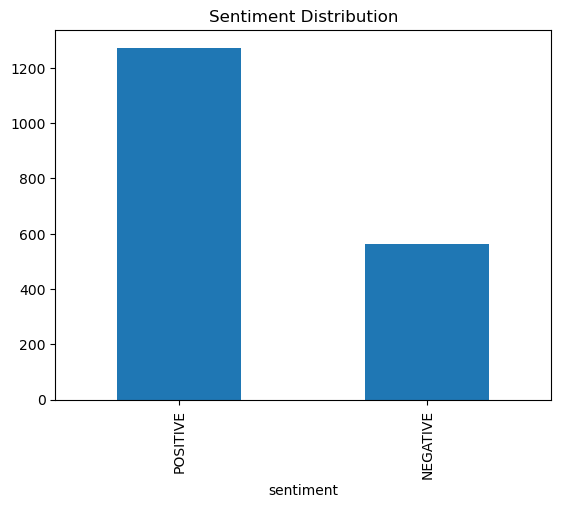

In [10]:
import matplotlib.pyplot as plt

reviews_df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()